# YOLO26-seg Seg-Grad-CAM 분석 (L1~L5 척추)

학습한 `yolo26m-seg` best.pt 모델이 **X-ray DICOM(.dcm)에서 어디를 보고 척추를 분할하는지**를
**gradient 기반 Seg-Grad-CAM** 히트맵으로 시각화합니다.

> EigenCAM은 class-agnostic(활성화의 제1주성분)이라 척추가 아니라 **이미지 테두리/패딩과
> 고대비 뼈**에 반응해 척추 에너지가 거의 0% 였습니다. 그래서 **L1~L5 인스턴스 마스크 스코어를
> 역전파하는 Seg-Grad-CAM**으로 교체했습니다.

- 모델: `best.pt` (yolo26m-seg, L1~L5)
- 입력: `.dcm` X-ray 파일들
- 방법: 각 척추(L1~L5) 인스턴스 마스크 확률 합을 **P3 neck feature**로 역전파한 GAP Grad-CAM
- 지표: `spine energy %` = 전체 CAM 에너지 중 척추 마스크에 실린 비율 (높을수록 척추 집중)

## 1. 패키지 준비 (yolo_cam clone)

In [ ]:
# Seg-Grad-CAM 버전에서는 외부 yolo_cam 패키지가 필요 없습니다.
# (gradient 기반이라 ultralytics 만으로 동작 -> 이 셀은 건너뛰어도 됩니다.)
print("Seg-Grad-CAM 사용: yolo_cam clone 불필요 (skip).")

In [ ]:
# 의존 패키지 설치 (필요 시 주석 해제)
# !pip install ultralytics pydicom opencv-python matplotlib numpy pillow
# YOLO26 지원을 위해 최신 ultralytics 권장:
# !pip install -U ultralytics

## 2. Import & 설정

In [ ]:
import os
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut

from ultralytics import YOLO

print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

In [3]:
# ===== 사용자 경로 설정 =====
MODEL_PATH = r"C:\Users\csm02\Desktop\edward\bmd\src\BMD\model\runs\segment\ap_seg\l1_l5_yolo26m_ap_la\weights\best.pt"
DCM_DIR    = r"C:\Users\csm02\Desktop\edward\bmd\src\BMD\model\dataset-dcm\test\gather"

OUT_DIR    = "cam_outputs"          # 결과 저장 폴더
IMGSZ      = 640                    # 모델 입력 크기 (학습 시와 맞추세요)
os.makedirs(OUT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## 3. DICOM 로더

`.dcm` → 8bit RGB numpy 로 변환합니다. VOI LUT / MONOCHROME1 반전 / 윈도우 정규화를 처리합니다.

In [4]:
def load_dicom_as_rgb(path):
    """DICOM 파일을 0~255 uint8 RGB 이미지로 변환."""
    ds = pydicom.dcmread(path)
    arr = ds.pixel_array

    # VOI LUT (windowing) 적용 시도
    try:
        arr = apply_voi_lut(arr, ds)
    except Exception:
        pass

    arr = arr.astype(np.float32)

    # MONOCHROME1 이면 흑백 반전
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        arr = arr.max() - arr

    # min-max 정규화 -> 0~255
    mn, mx = arr.min(), arr.max()
    if mx > mn:
        arr = (arr - mn) / (mx - mn)
    else:
        arr = np.zeros_like(arr)
    arr = (arr * 255.0).astype(np.uint8)

    # 흑백 -> 3채널
    if arr.ndim == 2:
        rgb = cv2.cvtColor(arr, cv2.COLOR_GRAY2RGB)
    else:
        rgb = arr
    return rgb


dcm_files = sorted(glob.glob(os.path.join(DCM_DIR, "*.dcm")))
print(f"찾은 DICOM 파일: {len(dcm_files)}개")
for f in dcm_files[:5]:
    print(" -", os.path.basename(f))

찾은 DICOM 파일: 42개
 - 1.2.826.0.1.3680043.8.498.10406657579016312201439626146133412368-c.dcm
 - 1.2.826.0.1.3680043.8.498.10947130043296900260026400505615377321-c.dcm
 - 1.2.826.0.1.3680043.8.498.11121020226184051416110461667223845149-c.dcm
 - 1.2.826.0.1.3680043.8.498.11207126462590105123217163368073993344-c.dcm
 - 1.2.826.0.1.3680043.8.498.11227155170490832168629184106125649390-c.dcm


## 4. 모델 로드 & Grad-CAM 설정

Seg-Grad-CAM은 gradient 기반이라 **head 로 feature 가 흘러가는 neck 레이어**를 타깃으로 잡고,
그 활성화맵에 대한 L1~L5 마스크-스코어의 gradient 로 CAM 을 만듭니다.
아래에서 모델 구조를 확인하고 `CAM_LAYER_IDX`(기본 16 = P3 / stride-8)를 필요 시 조정하세요.

In [5]:
model = YOLO(MODEL_PATH)
model.to(device)

# 내부 nn.Module 리스트 확인 (레이어 인덱스 파악용)
layers = model.model.model
print("총 레이어 수:", len(layers))
for i, l in enumerate(layers):
    print(f"[{i:2d}] {l.__class__.__name__}")

총 레이어 수: 24
[ 0] Conv
[ 1] Conv
[ 2] C3k2
[ 3] Conv
[ 4] C3k2
[ 5] Conv
[ 6] C3k2
[ 7] Conv
[ 8] C3k2
[ 9] SPPF
[10] C2PSA
[11] Upsample
[12] Concat
[13] C3k2
[14] Upsample
[15] Concat
[16] C3k2
[17] Conv
[18] Concat
[19] C3k2
[20] Conv
[21] Concat
[22] C3k2
[23] Segment26


In [ ]:
# ===== Seg-Grad-CAM 설정 (gradient 기반, 척추 집중) =====
CLASS_NAMES   = list(model.names.values())          # ['L1','L2','L3','L4','L5']
CAM_LAYER_IDX = 16                                  # P3 / stride-8 neck feature (head 입력, 고해상도)
SPINE_COLORS  = [(255, 0, 0), (255, 140, 0), (255, 220, 0), (0, 200, 0), (0, 90, 255)]  # L1~L5

# autograd 전용 모델: predict() 를 절대 호출하지 않은 신선한 로드
# (predict 가 캐시하는 inference-mode 텐서는 backward 그래프에 못 들어감)
_NET = YOLO(MODEL_PATH).model.to(device).eval()
for _p in _NET.parameters():
    _p.requires_grad_(True)
print("CAM target layer:", f"[{CAM_LAYER_IDX}]", _NET.model[CAM_LAYER_IDX].__class__.__name__)

def spine_grad_cam(rgb, imgsz=IMGSZ, layer_idx=CAM_LAYER_IDX, conf=0.25):
    """L1~L5 인스턴스 마스크 스코어(sigmoid(coeff·proto)) 합을 P3 neck feature 로 역전파한
       GAP Grad-CAM. returns (cam[imgsz,imgsz] in [0,1], masks {cls_id: bool[imgsz,imgsz]})."""
    img = cv2.resize(rgb, (imgsz, imgsz))
    t = torch.from_numpy(img.transpose(2, 0, 1).copy()).float().unsqueeze(0).to(device) / 255.0
    t.requires_grad_(True)
    acts = {}
    layer = _NET.model[layer_idx]
    h1 = layer.register_forward_hook(lambda m, i, o: acts.__setitem__('a', o))
    masks = {}
    try:
        _NET.model[-1].shape = None                        # anchor 재계산 강제 (autograd 안전)
        with torch.enable_grad():
            det, proto = _NET(t)[0]
            det, proto = det[0], proto[0]                  # [N,6+K], [K,P,P]
            K, P = proto.shape[0], proto.shape[-1]
            sc, cl = det[:, 4], det[:, 5]
            total = 0.0
            for c in range(len(CLASS_NAMES)):              # L1~L5 각 인스턴스 누적
                selc = torch.where((cl.round() == c) & (sc > conf))[0]
                if not len(selc):
                    continue
                a = selc[torch.argmax(sc[selc])]
                coeff = det[a][6:6 + K]
                prob = torch.sigmoid((coeff[:, None, None] * proto).sum(0))
                crop = torch.zeros_like(prob)
                x0, y0, x1, y1 = [int(v / 4) for v in det[a][:4]]
                x0, y0 = max(0, x0), max(0, y0); x1, y1 = min(P, x1), min(P, y1)
                crop[y0:y1, x0:x1] = 1.0
                pc = prob * crop
                total = total + (pc * (pc > 0.5).float().detach()).sum()
                masks[c] = cv2.resize(pc.detach().cpu().numpy().astype(np.float32), (imgsz, imgsz)) > 0.5
            if not isinstance(total, torch.Tensor):
                raise RuntimeError("no L1~L5 detections above conf")
            A = acts['a']
            g = torch.autograd.grad(total, A, allow_unused=True)[0]
            if g is None:
                raise RuntimeError(f"layer {layer_idx} is not upstream of the mask -> change CAM_LAYER_IDX")
            Aw, gw = A[0].detach(), g[0].detach()
            cam = torch.relu((gw.mean(dim=(1, 2), keepdim=True) * Aw).sum(0)).cpu().numpy()   # GAP Grad-CAM
    finally:
        h1.remove()
    cam = cv2.resize(cam.astype(np.float32), (imgsz, imgsz))
    cam = cv2.GaussianBlur(cam, (0, 0), sigmaX=imgsz / 150.0)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, masks

def cam_overlay(img640, cam, masks):
    """640 RGB + JET 히트맵 블렌드 + L1~L5 색상 윤곽선 (L1 빨강 … L5 파랑)."""
    heat = cv2.cvtColor(cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    out = (0.55 * img640 + 0.45 * heat).astype(np.uint8)
    for c, m in masks.items():
        col = SPINE_COLORS[c % len(SPINE_COLORS)]
        cnts, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        cv2.drawContours(out, cnts, -1, col, 2)
    return out

def spine_energy(cam, masks):
    """CAM 에너지 중 척추(L1~L5 마스크 합)에 실린 비율 -> EigenCAM(~0%) 대비 개선 지표."""
    if not masks:
        return 0.0
    spine = np.zeros(cam.shape, bool)
    for m in masks.values():
        spine |= m
    c = np.maximum(cam, 0)
    return float(c[spine].sum() / (c.sum() + 1e-9))

## 5. 단일 파일 Seg-Grad-CAM 테스트

먼저 한 장으로 정상 동작과 **척추 집중도(spine energy %)** 를 확인합니다.

In [ ]:
# 첫 번째 파일로 테스트
assert len(dcm_files) > 0, "DCM 파일을 찾지 못했습니다. DCM_DIR 경로를 확인하세요."

rgb = load_dicom_as_rgb(dcm_files[0])
img640 = cv2.resize(rgb, (IMGSZ, IMGSZ))
cam, masks = spine_grad_cam(rgb, IMGSZ, CAM_LAYER_IDX)
overlay = cam_overlay(img640, cam, masks)
e = spine_energy(cam, masks)

fig, ax = plt.subplots(1, 3, figsize=(16, 6))
ax[0].imshow(img640);          ax[0].set_title("Input (DICOM)");                        ax[0].axis("off")
ax[1].imshow(cam, cmap="jet"); ax[1].set_title("Spine Grad-CAM (gray)");                ax[1].axis("off")
ax[2].imshow(overlay);         ax[2].set_title(f"Overlay (spine energy = {e*100:.0f}%)"); ax[2].axis("off")
plt.suptitle(os.path.basename(dcm_files[0]))
plt.tight_layout(); plt.show()

### ⚠️ 만약 여기서 에러가 나면
- `target_layers` 인덱스를 `[-3]`, `[-4]` 등으로 바꿔보세요.
- 셀을 **한 번 더 실행**하면 되는 경우가 있습니다 (패키지 알려진 이슈, README 참고).
- YOLO26 미지원 에러면 `pip install -U ultralytics` 로 업데이트하세요.

## 6. 세그멘테이션 예측 + CAM 함께 보기 (선택)

모델의 실제 분할 마스크와 CAM을 나란히 비교하면 해석이 쉬워집니다.

In [ ]:
def visualize_pred_and_cam(dcm_path, imgsz=IMGSZ):
    rgb = load_dicom_as_rgb(dcm_path)
    img640 = cv2.resize(rgb, (imgsz, imgsz))

    # 예측 (마스크 오버레이용) — 여기선 `model` 사용. Grad-CAM 은 별도 `_NET`(predict 미사용)이라
    # 이 predict 호출이 grad-cam 을 오염시키지 않습니다.
    res = model.predict(img640, imgsz=imgsz, verbose=False, device=device)[0]
    pred_plot = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)

    # Seg-Grad-CAM
    cam, masks = spine_grad_cam(rgb, imgsz, CAM_LAYER_IDX)
    overlay = cam_overlay(img640, cam, masks)
    e = spine_energy(cam, masks)

    fig, ax = plt.subplots(1, 3, figsize=(16, 6))
    ax[0].imshow(img640);    ax[0].set_title("Input");                                   ax[0].axis("off")
    ax[1].imshow(pred_plot); ax[1].set_title("Seg Prediction");                          ax[1].axis("off")
    ax[2].imshow(overlay);   ax[2].set_title(f"Spine Grad-CAM (energy = {e*100:.0f}%)");  ax[2].axis("off")
    plt.suptitle(os.path.basename(dcm_path))
    plt.tight_layout(); plt.show()
    return overlay


_ = visualize_pred_and_cam(dcm_files[0], IMGSZ)

## 7. 전체 배치 처리 & 저장

`DCM_DIR` 안의 모든 `.dcm`에 대해 CAM을 계산하고 `cam_outputs/` 에 저장합니다.

In [ ]:
from PIL import Image

def process_all(dcm_files, out_dir, imgsz=IMGSZ, max_files=None):
    files = dcm_files if max_files is None else dcm_files[:max_files]
    saved = []
    for i, path in enumerate(files):
        try:
            rgb = load_dicom_as_rgb(path)
            img640 = cv2.resize(rgb, (imgsz, imgsz))
            cam, masks = spine_grad_cam(rgb, imgsz, CAM_LAYER_IDX)
            overlay = cam_overlay(img640, cam, masks)

            base = os.path.splitext(os.path.basename(path))[0]
            out_path = os.path.join(out_dir, f"{base}_cam.png")
            Image.fromarray(overlay).save(out_path)
            saved.append(out_path)
            print(f"[{i+1}/{len(files)}] spine {spine_energy(cam, masks)*100:4.0f}% -> {out_path}")
        except Exception as e:
            print(f"[{i+1}/{len(files)}] FAILED {os.path.basename(path)}: {e}")
    return saved


# 전체 실행 (테스트로 몇 장만 하려면 max_files=5)
saved = process_all(dcm_files, OUT_DIR, IMGSZ, max_files=None)
print(f"\n완료: {len(saved)}개 저장됨 -> {OUT_DIR}")

## 8. 결과 그리드로 미리보기

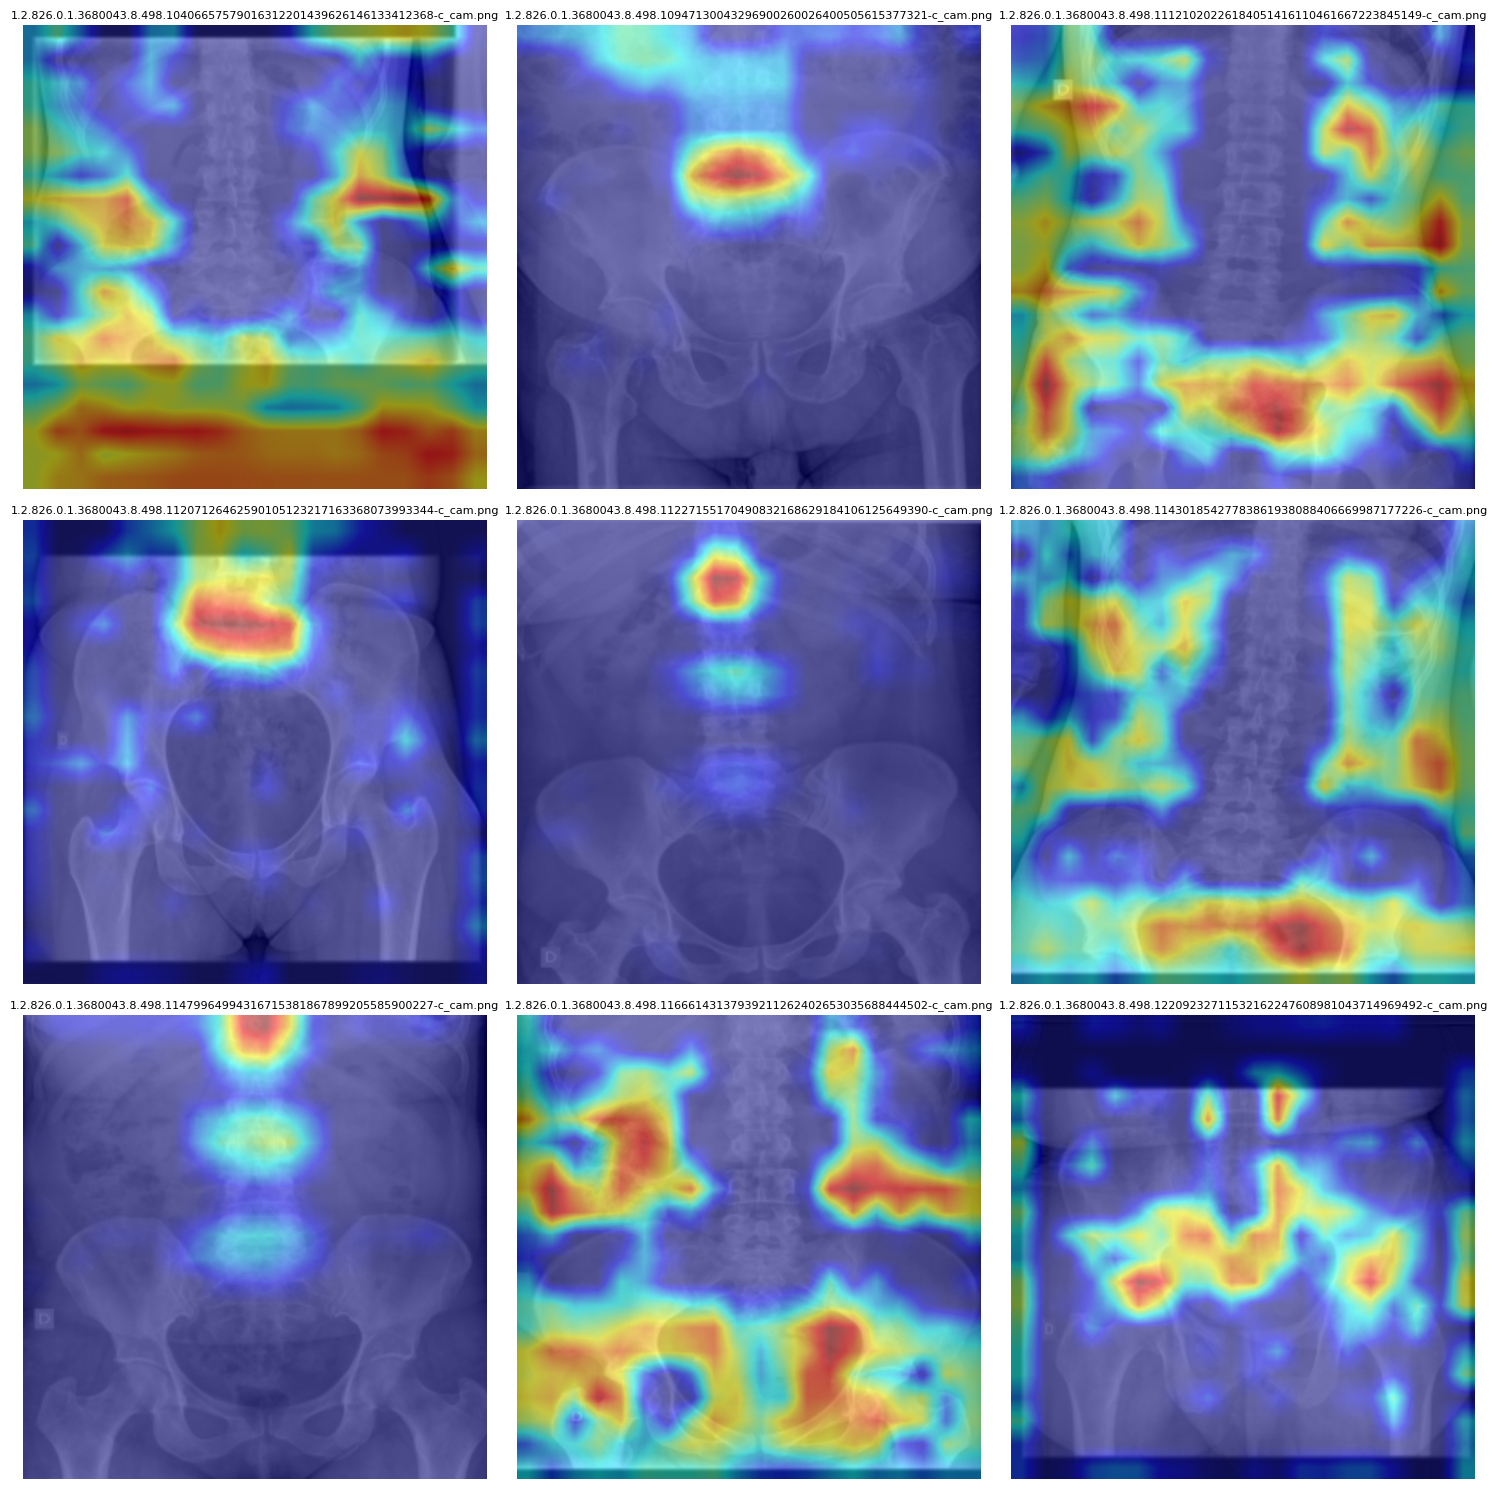

In [10]:
def show_grid(image_paths, cols=3, max_n=9):
    paths = image_paths[:max_n]
    if not paths:
        print("표시할 이미지가 없습니다."); return
    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    axes = np.array(axes).reshape(-1)
    for ax in axes: ax.axis("off")
    for ax, p in zip(axes, paths):
        ax.imshow(Image.open(p))
        ax.set_title(os.path.basename(p), fontsize=8)
    plt.tight_layout(); plt.show()

show_grid(saved, cols=3, max_n=9)

---
### 튜닝 팁
- **target layer**: `[-2]` → `[-3]`, `[-4]`, 또는 neck의 특정 C3k2/C2PSA 레이어. 척추 영역에 히트맵이 집중되는 레이어를 고르세요.
- **imgsz**: 학습 때 사용한 값(예: 640, 1024)과 맞추면 정렬이 정확합니다.
- **여러 CAM 방법**: 이 패키지는 EigenCAM 중심이지만, target layer만 바꿔도 관점이 크게 달라집니다.
- L1~L5를 개별로 보려면 예측 마스크로 ROI를 crop 한 뒤 각 척추별 CAM 평균값을 비교해 BMD 해석과 연결할 수 있습니다.